# **Titanic: Previsor de Sobrevivência — Árvore de Decisão**

Grupo 1 de SI:
Ana Maria, Eduardo Mabesoone, Heitor Riquelme, Pedro Herculano, Pedro Santana

## **Importações**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    log_loss, mean_squared_error
)
from sklearn.utils import resample

## **Carregamento do Dataset**

In [ ]:
!gdown --id 1AoYeR_iTQuM3V1eMYykZuw8LC6reuerQ
df = pd.read_csv('train.csv')
display(df.head(10))

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1AoYeR_iTQuM3V1eMYykZuw8LC6reuerQ
To: /content/train.csv
100% 61.2k/61.2k [00:00<00:00, 69.7MB/s]


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


## **Divisão dos Dados (50% Treino / 25% Validação / 25% Teste)**

In [ ]:
df_train, df_temp = train_test_split(
    df, test_size=0.5, stratify=df['Survived'], random_state=42
)
df_val, df_test = train_test_split(
    df_temp, test_size=0.5, stratify=df_temp['Survived'], random_state=42
)

for nome, split in [('Treino', df_train), ('Validação', df_val), ('Teste', df_test)]:
    print(f'{nome}: {len(split)} amostras | Taxa de sobrevivência: {split["Survived"].mean():.2%}')

Treino: 445 amostras | Taxa de sobrevivência: 38.43%
Validação: 223 amostras | Taxa de sobrevivência: 38.57%
Teste: 223 amostras | Taxa de sobrevivência: 38.12%


---
## **PARTE 1 — Baseline (Dados Brutos)**

> Árvore de Decisão com parâmetros default aplicada diretamente nos dados brutos
> (apenas colunas numéricas, nulos preenchidos com mediana).
> Serve como referência para medir o ganho do pré-processamento.

In [ ]:
def preparar_baseline(df_input):
    df = df_input.copy()
    target = df['Survived']
    df = df.drop(columns=['Survived'])
    df = df.select_dtypes(include=[np.number])
    df = df.fillna(df.median())
    return df, target

X_base_train, y_base_train = preparar_baseline(df_train)
X_base_val,   y_base_val   = preparar_baseline(df_val)
X_base_test,  y_base_test  = preparar_baseline(df_test)

print('Colunas usadas no baseline:', X_base_train.columns.tolist())
print(f'Shape treino: {X_base_train.shape}')

Colunas usadas no baseline: ['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Shape treino: (445, 6)


In [ ]:
dt_baseline = DecisionTreeClassifier(random_state=42)
dt_baseline.fit(X_base_train, y_base_train)

print('=== BASELINE — Árvore de Decisão (dados brutos, parâmetros default) ===')
for nome, X, y in [('Treino',    X_base_train, y_base_train),
                   ('Validação', X_base_val,   y_base_val),
                   ('Teste',     X_base_test,  y_base_test)]:
    pred = dt_baseline.predict(X)
    print(f'\n[{nome}]')
    print(f'  Acurácia : {accuracy_score(y, pred):.4f}')
    print(f'  Precisão : {precision_score(y, pred):.4f}')
    print(f'  Recall   : {recall_score(y, pred):.4f}')
    print(f'  F1-Score : {f1_score(y, pred):.4f}')

=== BASELINE — Árvore de Decisão (dados brutos, parâmetros default) ===

[Treino]
  Acurácia : 1.0000
  Precisão : 1.0000
  Recall   : 1.0000
  F1-Score : 1.0000

[Validação]
  Acurácia : 0.6323
  Precisão : 0.5312
  Recall   : 0.3953
  F1-Score : 0.4533

[Teste]
  Acurácia : 0.6323
  Precisão : 0.5181
  Recall   : 0.5059
  F1-Score : 0.5119


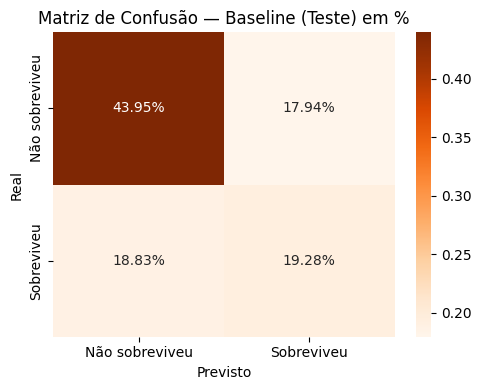


Profundidade da árvore baseline : 18
Número de folhas                 : 119


In [ ]:
cm_base = confusion_matrix(y_base_test, dt_baseline.predict(X_base_test))
cm_base_pct = cm_base / cm_base.sum()

plt.figure(figsize=(5, 4))
sns.heatmap(cm_base_pct, annot=True, fmt='.2%', cmap='Oranges',
            xticklabels=['Não sobreviveu', 'Sobreviveu'],
            yticklabels=['Não sobreviveu', 'Sobreviveu'])
plt.title('Matriz de Confusão — Baseline (Teste) em %')
plt.ylabel('Real'); plt.xlabel('Previsto')
plt.tight_layout(); plt.show()

print(f'\nProfundidade da árvore baseline : {dt_baseline.get_depth()}')
print(f'Número de folhas                 : {dt_baseline.get_n_leaves()}')

---
## **PARTE 2 — Pré-processamento Completo**

### **Análise Exploratória**

In [ ]:
print(df_train.shape)
print(df_train.dtypes)
display(df_train.describe())
print('\nValores nulos por coluna:')
print(df_train.isnull().sum())

(445, 12)
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,445.000000,445.00000,445.000000,354.000000,445.000000,445.000000,445.000000
mean,440.919101,0.38427,2.316854,30.558390,0.422472,0.364045,31.041854
std,265.123246,0.48697,0.838708,14.732869,0.896157,0.787036,45.907556
min,1.000000,0.00000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,211.000000,0.00000,2.000000,21.000000,0.000000,0.000000,7.895800
50%,441.000000,0.00000,3.000000,29.000000,0.000000,0.000000,14.454200
75%,675.000000,1.00000,3.000000,39.000000,1.000000,0.000000,30.000000
max,891.000000,1.00000,3.000000,80.000000,8.000000,5.000000,512.329200



Valores nulos por coluna:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             91
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          346
Embarked         1
dtype: int64


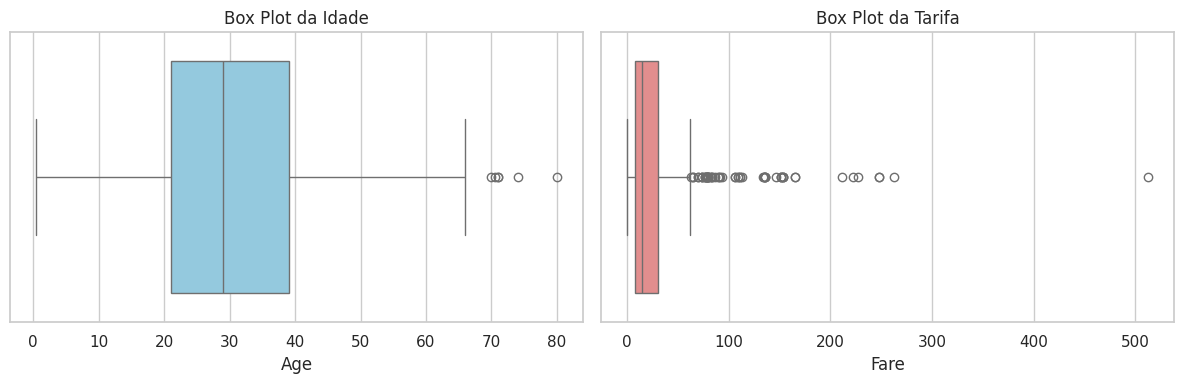

In [ ]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df_train['Age'].dropna(), ax=axes[0], color='skyblue')
axes[0].set_title('Box Plot da Idade')
sns.boxplot(x=df_train['Fare'], ax=axes[1], color='lightcoral')
axes[1].set_title('Box Plot da Tarifa')
plt.tight_layout(); plt.show()

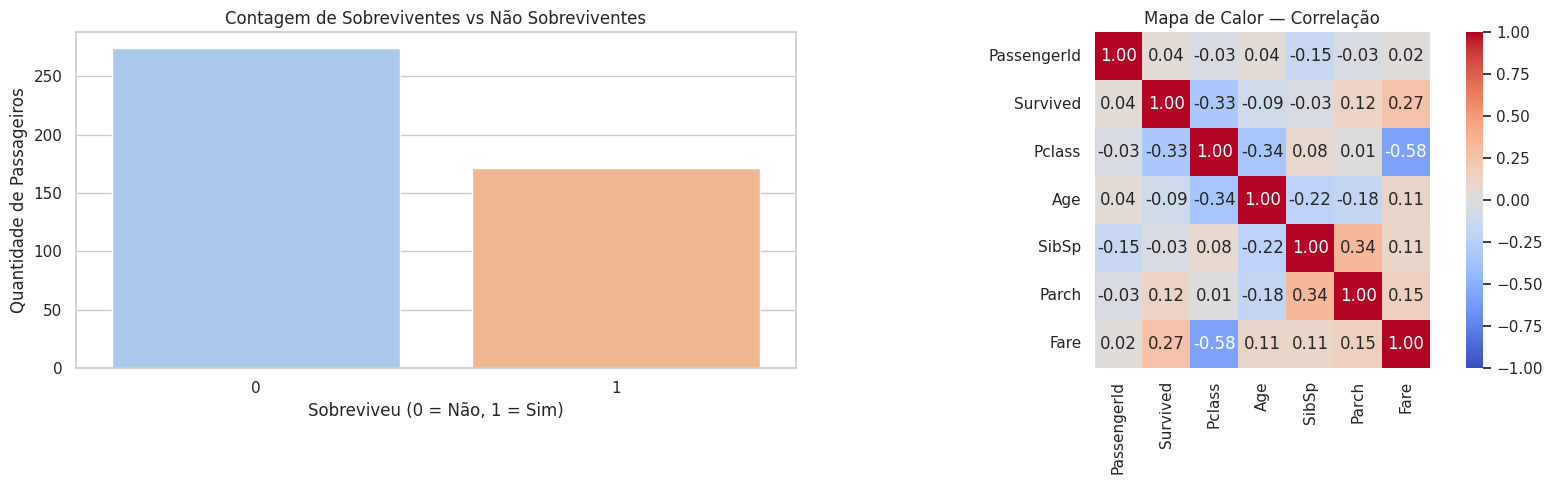

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.countplot(x='Survived', data=df_train, ax=axes[0], palette='pastel')
axes[0].set_title('Contagem de Sobreviventes vs Não Sobreviventes')
axes[0].set_xlabel('Sobreviveu (0 = Não, 1 = Sim)')
axes[0].set_ylabel('Quantidade de Passageiros')
colunas_num = df_train.select_dtypes(include=['float64', 'int64'])
sns.heatmap(colunas_num.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            square=True, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Mapa de Calor — Correlação')
plt.tight_layout(); plt.show()

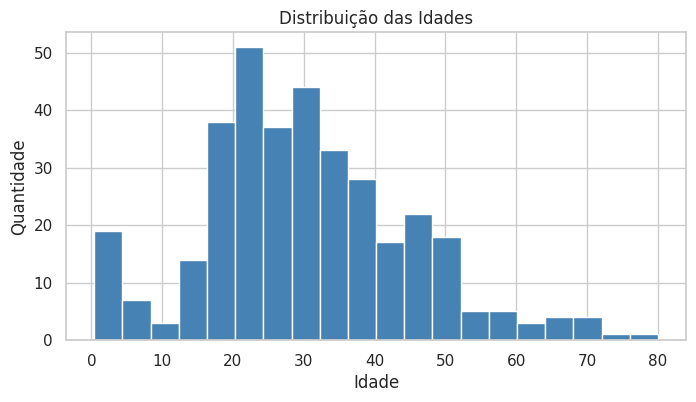

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(df_train['Age'].dropna(), bins=20, color='steelblue', edgecolor='white')
plt.xlabel('Idade'); plt.ylabel('Quantidade')
plt.title('Distribuição das Idades')
plt.show()

In [ ]:
df_train['Cabin_known'] = df_train['Cabin'].notna().astype(int)
survival_by_cabin = df_train.groupby('Cabin_known')['Survived'].mean()
print('Taxa de sobrevivência por conhecimento de cabine:')
print(survival_by_cabin.rename({0: 'Cabine desconhecida', 1: 'Cabine conhecida'}))

Taxa de sobrevivência por conhecimento de cabine:
Cabin_known
Cabine desconhecida    0.297688
Cabine conhecida       0.686869
Name: Survived, dtype: float64


### **Pré-processamento**

In [ ]:
CABINE_LETRAS       = list('TGFEDCBA')
COLUNAS_INUTEIS     = ['PassengerId', 'Ticket']
COLUNAS_NUMERICAS   = ['Fare', 'SibSp', 'Parch']
COLUNAS_CATEGORICAS = ['Pclass', 'Name', 'Sex', 'Cabin', 'Embarked', 'Age_cut']

def extrair_titulo(name: str) -> str:
    rare_patterns = ["Mrs ", "Mr ", "Don", "Jonkheer"]
    title_map = [
        ("Mr.",      "Mr."),   ("Mrs.",    "Mrs."),
        ("Miss.",    "Miss."), ("Master.", "Master."),
        ("Dr.",      "Dr."),   ("Rev.",    "Rev."),
        ("Col.",     "Col."),  ("Major.",  "Major."),
        ("Mlle.",    "Mlle."), ("Capt.",   "Ms."),
        ("Ms.",      "Ms."),   ("Mme.",    "Mme."),
        ("Countess", "Countess"),
    ]
    for pattern in rare_patterns:
        if pattern in name: return "Rare"
    for pattern, title in title_map:
        if pattern in name: return title
    return "Unknown"

def extrair_letra_cabine(cabine):
    if pd.isna(cabine): return 'NOT_INFORMED'
    for letra in CABINE_LETRAS:
        if letra in str(cabine): return letra
    return 'NOT_INFORMED'

def preprocessar(df_input, scaler=None, fit_scaler=False, colunas_treino=None):
    df = df_input.copy().reset_index(drop=True)
    df['Name']     = df['Name'].apply(extrair_titulo)
    df['Cabin']    = df['Cabin'].apply(extrair_letra_cabine)
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
    mediana_por_titulo = df.groupby('Name')['Age'].median()
    df['Age'] = df.apply(
        lambda row: mediana_por_titulo[row['Name']] if pd.isna(row['Age']) else row['Age'], axis=1
    )
    df['Age_cut'] = pd.cut(df['Age'], bins=[0, 18, 25, 40, float('inf')],
                            labels=['0-18', '18-25', '25-40', '40+'],
                            right=True, include_lowest=True)
    df = df.drop(columns=COLUNAS_INUTEIS + ['Age'])
    target = df['Survived']; df = df.drop(columns=['Survived'])
    if fit_scaler:
        scaler = MinMaxScaler()
        df[['Fare_norm', 'SibSp_norm', 'Parch_norm']] = scaler.fit_transform(df[COLUNAS_NUMERICAS])
    else:
        df[['Fare_norm', 'SibSp_norm', 'Parch_norm']] = scaler.transform(df[COLUNAS_NUMERICAS])
    df = df.drop(columns=COLUNAS_NUMERICAS)
    df = pd.get_dummies(df, columns=COLUNAS_CATEGORICAS)
    if colunas_treino is not None:
        df = df.reindex(columns=colunas_treino, fill_value=0)
    return df, target, scaler

In [ ]:
X_train, y_train, scaler = preprocessar(df_train, fit_scaler=True)
colunas_treino = X_train.columns.tolist()
X_val,  y_val,  _ = preprocessar(df_val,  scaler=scaler, colunas_treino=colunas_treino)
X_test, y_test, _ = preprocessar(df_test, scaler=scaler, colunas_treino=colunas_treino)
print(f'X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}')

X_train: (445, 32) | X_val: (223, 32) | X_test: (223, 32)


### **Balanceamento de Classes (Oversampling)**

In [ ]:
print('Distribuição antes do balanceamento:')
print(y_train.value_counts())

train_df   = X_train.copy()
train_df['Survived'] = y_train.values
majoritaria = train_df[train_df['Survived'] == 0]
minoritaria = train_df[train_df['Survived'] == 1]
minoritaria_oversampled = resample(
    minoritaria, replace=True, n_samples=len(majoritaria), random_state=42
)
train_balanceado = pd.concat([majoritaria, minoritaria_oversampled]).sample(frac=1, random_state=42)
X_train_bal = train_balanceado.drop(columns=['Survived'])
y_train_bal = train_balanceado['Survived']

print('\nDistribuição após balanceamento:')
print(y_train_bal.value_counts())

Distribuição antes do balanceamento:
Survived
0    274
1    171
Name: count, dtype: int64

Distribuição após balanceamento:
Survived
0    274
1    274
Name: count, dtype: int64


---
## **PARTE 3 — Variação de Hiperparâmetros**

> Ao final de cada experimento, o melhor valor encontrado é salvo automaticamente
> no dicionário `best_params` e usado na construção do modelo final.

In [ ]:
# Dicionário que acumula os melhores hiperparâmetros conforme os experimentos são executados
best_params = {
    'max_depth'            : None,
    'min_samples_split'    : 2,
    'min_samples_leaf'     : 1,
    'max_leaf_nodes'       : None,
    'max_features'         : None,
    'min_impurity_decrease': 0.0,
}
print('Dicionário de hiperparâmetros iniciado:', best_params)

Dicionário de hiperparâmetros iniciado: {'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_leaf_nodes': None, 'max_features': None, 'min_impurity_decrease': 0.0}


### **Experimento 1 — max_depth (Profundidade Máxima)**

max_depth=1     | Acurácia: 0.8161 | F1: 0.7760
max_depth=2     | Acurácia: 0.8520 | F1: 0.8047
max_depth=3     | Acurácia: 0.8206 | F1: 0.7849
max_depth=4     | Acurácia: 0.8161 | F1: 0.7389
max_depth=5     | Acurácia: 0.8251 | F1: 0.7665
max_depth=6     | Acurácia: 0.8296 | F1: 0.7654
max_depth=8     | Acurácia: 0.7803 | F1: 0.6994
max_depth=10    | Acurácia: 0.7713 | F1: 0.6909
max_depth=15    | Acurácia: 0.7713 | F1: 0.6832
max_depth=None  | Acurácia: 0.7713 | F1: 0.6832

✅ Melhor max_depth → 2 (F1: 0.8047)
   best_params atualizado: {'max_depth': 2, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_leaf_nodes': None, 'max_features': None, 'min_impurity_decrease': 0.0}


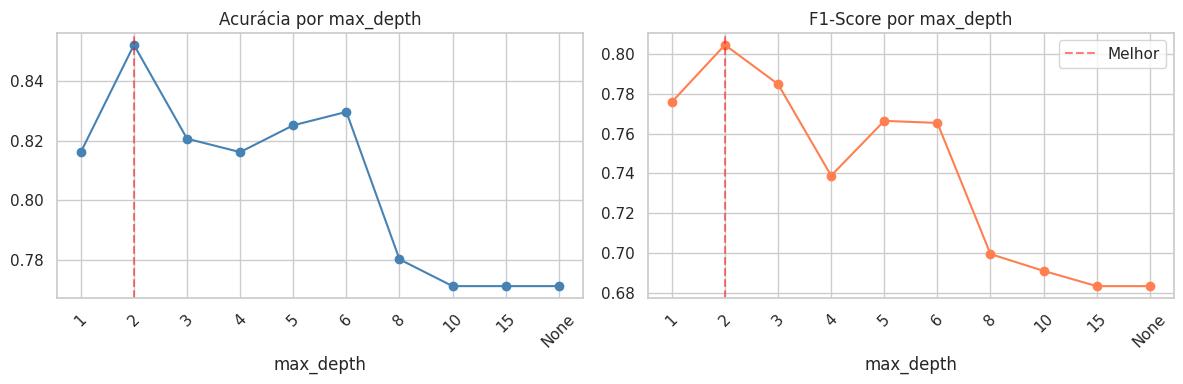

In [ ]:
profundidades = [1, 2, 3, 4, 5, 6, 8, 10, 15, None]
resultados_depth = []

for depth in profundidades:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train_bal, y_train_bal)
    acc_val = accuracy_score(y_val, dt.predict(X_val))
    f1_val  = f1_score(y_val, dt.predict(X_val))
    resultados_depth.append({'max_depth': str(depth), 'Acurácia Val': acc_val, 'F1 Val': f1_val})
    print(f'max_depth={str(depth):5s} | Acurácia: {acc_val:.4f} | F1: {f1_val:.4f}')

df_depth = pd.DataFrame(resultados_depth)
melhor_idx   = df_depth['F1 Val'].idxmax()
melhor_depth = profundidades[melhor_idx]

# ── Atualiza best_params automaticamente ──
best_params['max_depth'] = melhor_depth
print(f'\n✅ Melhor max_depth → {melhor_depth} (F1: {df_depth.loc[melhor_idx, "F1 Val"]:.4f})')
print(f'   best_params atualizado: {best_params}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(len(df_depth)), df_depth['Acurácia Val'], marker='o', color='steelblue')
axes[0].set_xticks(range(len(df_depth))); axes[0].set_xticklabels(df_depth['max_depth'], rotation=45)
axes[0].set_title('Acurácia por max_depth'); axes[0].set_xlabel('max_depth')
axes[0].axvline(melhor_idx, color='red', linestyle='--', alpha=0.5)
axes[1].plot(range(len(df_depth)), df_depth['F1 Val'], marker='o', color='coral')
axes[1].set_xticks(range(len(df_depth))); axes[1].set_xticklabels(df_depth['max_depth'], rotation=45)
axes[1].set_title('F1-Score por max_depth'); axes[1].set_xlabel('max_depth')
axes[1].axvline(melhor_idx, color='red', linestyle='--', alpha=0.5, label='Melhor')
axes[1].legend()
plt.tight_layout(); plt.show()

### **Experimento 2 — min_samples_split**

min_samples_split=   2 | Acurácia: 0.8520 | F1: 0.8047
min_samples_split=   5 | Acurácia: 0.8520 | F1: 0.8047
min_samples_split=  10 | Acurácia: 0.8520 | F1: 0.8047
min_samples_split=  20 | Acurácia: 0.8520 | F1: 0.8047
min_samples_split=  30 | Acurácia: 0.8520 | F1: 0.8047
min_samples_split=  50 | Acurácia: 0.8520 | F1: 0.8047
min_samples_split= 100 | Acurácia: 0.8520 | F1: 0.8047

✅ Melhor min_samples_split → 2 (F1: 0.8047)
   best_params atualizado: {'max_depth': 2, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_leaf_nodes': None, 'max_features': None, 'min_impurity_decrease': 0.0}


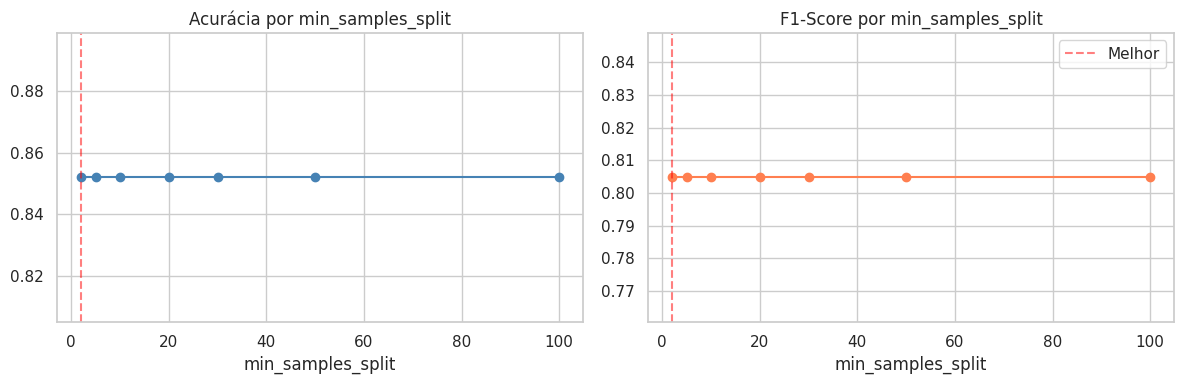

In [ ]:
min_splits = [2, 5, 10, 20, 30, 50, 100]
resultados_split = []

for ms in min_splits:
    dt = DecisionTreeClassifier(max_depth=best_params['max_depth'], min_samples_split=ms, random_state=42)
    dt.fit(X_train_bal, y_train_bal)
    acc_val = accuracy_score(y_val, dt.predict(X_val))
    f1_val  = f1_score(y_val, dt.predict(X_val))
    resultados_split.append({'min_samples_split': ms, 'Acurácia Val': acc_val, 'F1 Val': f1_val})
    print(f'min_samples_split={ms:4d} | Acurácia: {acc_val:.4f} | F1: {f1_val:.4f}')

df_split     = pd.DataFrame(resultados_split)
melhor_idx   = df_split['F1 Val'].idxmax()
melhor_split = min_splits[melhor_idx]

# ── Atualiza best_params automaticamente ──
best_params['min_samples_split'] = melhor_split
print(f'\n✅ Melhor min_samples_split → {melhor_split} (F1: {df_split.loc[melhor_idx, "F1 Val"]:.4f})')
print(f'   best_params atualizado: {best_params}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(df_split['min_samples_split'], df_split['Acurácia Val'], marker='o', color='steelblue')
axes[0].axvline(melhor_split, color='red', linestyle='--', alpha=0.5)
axes[0].set_title('Acurácia por min_samples_split'); axes[0].set_xlabel('min_samples_split')
axes[1].plot(df_split['min_samples_split'], df_split['F1 Val'], marker='o', color='coral')
axes[1].axvline(melhor_split, color='red', linestyle='--', alpha=0.5, label='Melhor')
axes[1].set_title('F1-Score por min_samples_split'); axes[1].set_xlabel('min_samples_split')
axes[1].legend()
plt.tight_layout(); plt.show()

### **Experimento 3 — min_samples_leaf**

min_samples_leaf=   1 | Acurácia: 0.8520 | F1: 0.8047
min_samples_leaf=   2 | Acurácia: 0.8520 | F1: 0.8047
min_samples_leaf=   5 | Acurácia: 0.8520 | F1: 0.8047
min_samples_leaf=  10 | Acurácia: 0.8520 | F1: 0.8047
min_samples_leaf=  15 | Acurácia: 0.8161 | F1: 0.7760
min_samples_leaf=  20 | Acurácia: 0.8161 | F1: 0.7760
min_samples_leaf=  30 | Acurácia: 0.8161 | F1: 0.7760
min_samples_leaf=  50 | Acurácia: 0.8161 | F1: 0.7760

✅ Melhor min_samples_leaf → 1 (F1: 0.8047)
   best_params atualizado: {'max_depth': 2, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_leaf_nodes': None, 'max_features': None, 'min_impurity_decrease': 0.0}


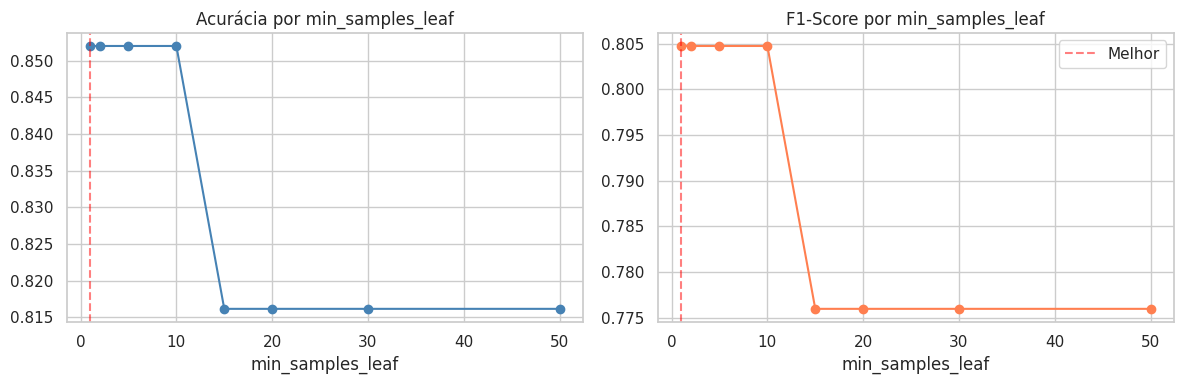

In [ ]:
min_leafs = [1, 2, 5, 10, 15, 20, 30, 50]
resultados_leaf = []

for ml in min_leafs:
    dt = DecisionTreeClassifier(
        max_depth=best_params['max_depth'],
        min_samples_split=best_params['min_samples_split'],
        min_samples_leaf=ml, random_state=42
    )
    dt.fit(X_train_bal, y_train_bal)
    acc_val = accuracy_score(y_val, dt.predict(X_val))
    f1_val  = f1_score(y_val, dt.predict(X_val))
    resultados_leaf.append({'min_samples_leaf': ml, 'Acurácia Val': acc_val, 'F1 Val': f1_val})
    print(f'min_samples_leaf={ml:4d} | Acurácia: {acc_val:.4f} | F1: {f1_val:.4f}')

df_leaf     = pd.DataFrame(resultados_leaf)
melhor_idx  = df_leaf['F1 Val'].idxmax()
melhor_leaf = min_leafs[melhor_idx]

# ── Atualiza best_params automaticamente ──
best_params['min_samples_leaf'] = melhor_leaf
print(f'\n✅ Melhor min_samples_leaf → {melhor_leaf} (F1: {df_leaf.loc[melhor_idx, "F1 Val"]:.4f})')
print(f'   best_params atualizado: {best_params}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(df_leaf['min_samples_leaf'], df_leaf['Acurácia Val'], marker='o', color='steelblue')
axes[0].axvline(melhor_leaf, color='red', linestyle='--', alpha=0.5)
axes[0].set_title('Acurácia por min_samples_leaf'); axes[0].set_xlabel('min_samples_leaf')
axes[1].plot(df_leaf['min_samples_leaf'], df_leaf['F1 Val'], marker='o', color='coral')
axes[1].axvline(melhor_leaf, color='red', linestyle='--', alpha=0.5, label='Melhor')
axes[1].set_title('F1-Score por min_samples_leaf'); axes[1].set_xlabel('min_samples_leaf')
axes[1].legend()
plt.tight_layout(); plt.show()

### **Experimento 4 — max_leaf_nodes**

max_leaf_nodes=2     | Acurácia: 0.8161 | F1: 0.7760
max_leaf_nodes=4     | Acurácia: 0.8520 | F1: 0.8047
max_leaf_nodes=8     | Acurácia: 0.8520 | F1: 0.8047
max_leaf_nodes=16    | Acurácia: 0.8520 | F1: 0.8047
max_leaf_nodes=32    | Acurácia: 0.8520 | F1: 0.8047
max_leaf_nodes=64    | Acurácia: 0.8520 | F1: 0.8047
max_leaf_nodes=128   | Acurácia: 0.8520 | F1: 0.8047
max_leaf_nodes=None  | Acurácia: 0.8520 | F1: 0.8047

✅ Melhor max_leaf_nodes → 4 (F1: 0.8047)
   best_params atualizado: {'max_depth': 2, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_leaf_nodes': 4, 'max_features': None, 'min_impurity_decrease': 0.0}


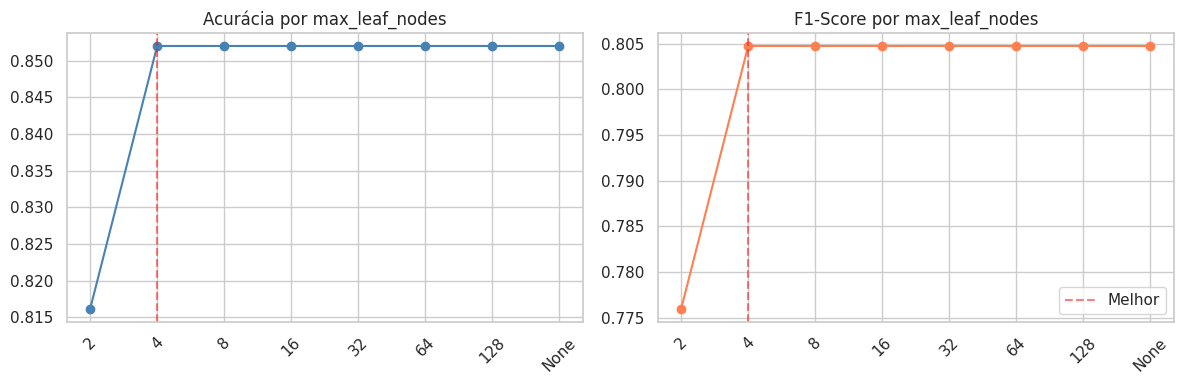

In [ ]:
max_leaves = [2, 4, 8, 16, 32, 64, 128, None]
resultados_leaves = []

for ml in max_leaves:
    dt = DecisionTreeClassifier(
        max_depth=best_params['max_depth'],
        min_samples_split=best_params['min_samples_split'],
        min_samples_leaf=best_params['min_samples_leaf'],
        max_leaf_nodes=ml, random_state=42
    )
    dt.fit(X_train_bal, y_train_bal)
    acc_val = accuracy_score(y_val, dt.predict(X_val))
    f1_val  = f1_score(y_val, dt.predict(X_val))
    resultados_leaves.append({'max_leaf_nodes': str(ml), 'Acurácia Val': acc_val, 'F1 Val': f1_val})
    print(f'max_leaf_nodes={str(ml):5s} | Acurácia: {acc_val:.4f} | F1: {f1_val:.4f}')

df_leaves      = pd.DataFrame(resultados_leaves)
melhor_idx     = df_leaves['F1 Val'].idxmax()
melhor_leaves  = max_leaves[melhor_idx]

# ── Atualiza best_params automaticamente ──
best_params['max_leaf_nodes'] = melhor_leaves
print(f'\n✅ Melhor max_leaf_nodes → {melhor_leaves} (F1: {df_leaves.loc[melhor_idx, "F1 Val"]:.4f})')
print(f'   best_params atualizado: {best_params}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(len(df_leaves)), df_leaves['Acurácia Val'], marker='o', color='steelblue')
axes[0].set_xticks(range(len(df_leaves))); axes[0].set_xticklabels(df_leaves['max_leaf_nodes'], rotation=45)
axes[0].set_title('Acurácia por max_leaf_nodes')
axes[0].axvline(melhor_idx, color='red', linestyle='--', alpha=0.5)
axes[1].plot(range(len(df_leaves)), df_leaves['F1 Val'], marker='o', color='coral')
axes[1].set_xticks(range(len(df_leaves))); axes[1].set_xticklabels(df_leaves['max_leaf_nodes'], rotation=45)
axes[1].set_title('F1-Score por max_leaf_nodes')
axes[1].axvline(melhor_idx, color='red', linestyle='--', alpha=0.5, label='Melhor')
axes[1].legend()
plt.tight_layout(); plt.show()

### **Experimento 5 — max_features**

max_features=sqrt   | Acurácia: 0.7758 | F1: 0.7059
max_features=log2   | Acurácia: 0.7758 | F1: 0.7059
max_features=0.3    | Acurácia: 0.8161 | F1: 0.7760
max_features=0.5    | Acurácia: 0.8520 | F1: 0.8047
max_features=0.7    | Acurácia: 0.8296 | F1: 0.7957
max_features=1.0    | Acurácia: 0.8520 | F1: 0.8047
max_features=None   | Acurácia: 0.8520 | F1: 0.8047

✅ Melhor max_features → 0.5 (F1: 0.8047)
   best_params atualizado: {'max_depth': 2, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_leaf_nodes': 4, 'max_features': 0.5, 'min_impurity_decrease': 0.0}


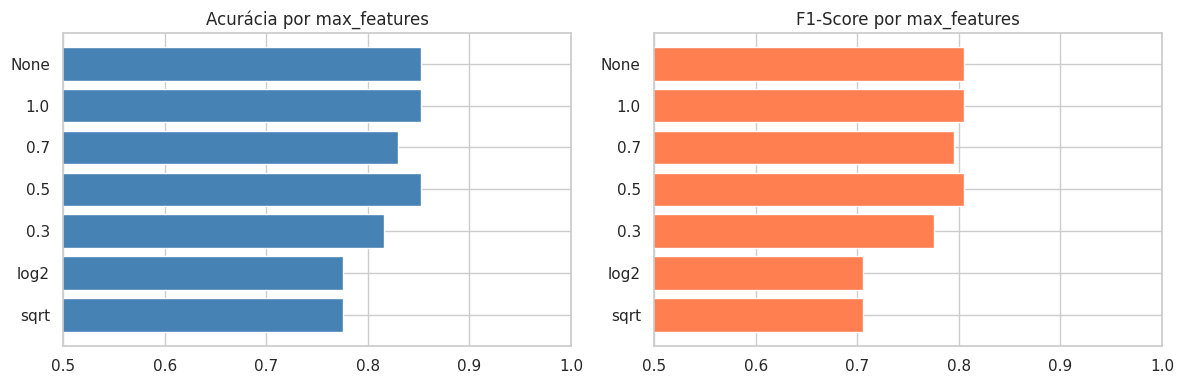

In [ ]:
max_features_opts = ['sqrt', 'log2', 0.3, 0.5, 0.7, 1.0, None]
resultados_features = []

for mf in max_features_opts:
    dt = DecisionTreeClassifier(
        max_depth=best_params['max_depth'],
        min_samples_split=best_params['min_samples_split'],
        min_samples_leaf=best_params['min_samples_leaf'],
        max_leaf_nodes=best_params['max_leaf_nodes'],
        max_features=mf, random_state=42
    )
    dt.fit(X_train_bal, y_train_bal)
    acc_val = accuracy_score(y_val, dt.predict(X_val))
    f1_val  = f1_score(y_val, dt.predict(X_val))
    resultados_features.append({'max_features': str(mf), 'Acurácia Val': acc_val, 'F1 Val': f1_val})
    print(f'max_features={str(mf):6s} | Acurácia: {acc_val:.4f} | F1: {f1_val:.4f}')

df_features      = pd.DataFrame(resultados_features)
melhor_idx       = df_features['F1 Val'].idxmax()
melhor_features  = max_features_opts[melhor_idx]

# ── Atualiza best_params automaticamente ──
best_params['max_features'] = melhor_features
print(f'\n✅ Melhor max_features → {melhor_features} (F1: {df_features.loc[melhor_idx, "F1 Val"]:.4f})')
print(f'   best_params atualizado: {best_params}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].barh(df_features['max_features'], df_features['Acurácia Val'], color='steelblue')
axes[0].set_title('Acurácia por max_features'); axes[0].set_xlim(0.5, 1.0)
axes[1].barh(df_features['max_features'], df_features['F1 Val'], color='coral')
axes[1].set_title('F1-Score por max_features'); axes[1].set_xlim(0.5, 1.0)
plt.tight_layout(); plt.show()

### **Experimento 6 — min_impurity_decrease**

min_impurity_decrease=0.0000 | Acurácia: 0.8520 | F1: 0.8047
min_impurity_decrease=0.0001 | Acurácia: 0.8520 | F1: 0.8047
min_impurity_decrease=0.0010 | Acurácia: 0.8520 | F1: 0.8047
min_impurity_decrease=0.0050 | Acurácia: 0.8520 | F1: 0.8047
min_impurity_decrease=0.0100 | Acurácia: 0.8520 | F1: 0.8047
min_impurity_decrease=0.0200 | Acurácia: 0.8520 | F1: 0.8047
min_impurity_decrease=0.0500 | Acurácia: 0.8161 | F1: 0.7760

✅ Melhor min_impurity_decrease → 0.0 (F1: 0.8047)
   best_params atualizado: {'max_depth': 2, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_leaf_nodes': 4, 'max_features': 0.5, 'min_impurity_decrease': 0.0}


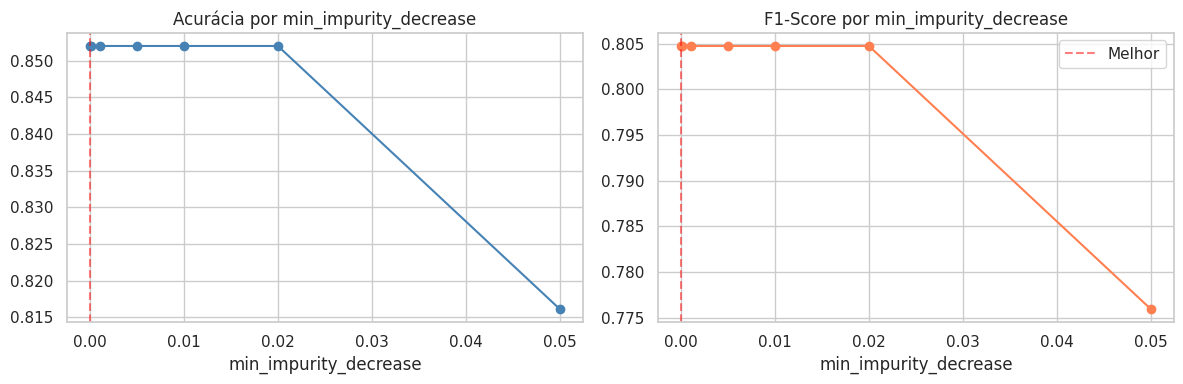

In [ ]:
impurezas = [0.0, 0.0001, 0.001, 0.005, 0.01, 0.02, 0.05]
resultados_impurity = []

for imp in impurezas:
    dt = DecisionTreeClassifier(
        max_depth=best_params['max_depth'],
        min_samples_split=best_params['min_samples_split'],
        min_samples_leaf=best_params['min_samples_leaf'],
        max_leaf_nodes=best_params['max_leaf_nodes'],
        max_features=best_params['max_features'],
        min_impurity_decrease=imp, random_state=42
    )
    dt.fit(X_train_bal, y_train_bal)
    acc_val = accuracy_score(y_val, dt.predict(X_val))
    f1_val  = f1_score(y_val, dt.predict(X_val))
    resultados_impurity.append({'min_impurity_decrease': imp, 'Acurácia Val': acc_val, 'F1 Val': f1_val})
    print(f'min_impurity_decrease={imp:.4f} | Acurácia: {acc_val:.4f} | F1: {f1_val:.4f}')

df_impurity      = pd.DataFrame(resultados_impurity)
melhor_idx       = df_impurity['F1 Val'].idxmax()
melhor_impurity  = impurezas[melhor_idx]

# ── Atualiza best_params automaticamente ──
best_params['min_impurity_decrease'] = melhor_impurity
print(f'\n✅ Melhor min_impurity_decrease → {melhor_impurity} (F1: {df_impurity.loc[melhor_idx, "F1 Val"]:.4f})')
print(f'   best_params atualizado: {best_params}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(df_impurity['min_impurity_decrease'], df_impurity['Acurácia Val'], marker='o', color='steelblue')
axes[0].axvline(melhor_impurity, color='red', linestyle='--', alpha=0.5)
axes[0].set_title('Acurácia por min_impurity_decrease'); axes[0].set_xlabel('min_impurity_decrease')
axes[1].plot(df_impurity['min_impurity_decrease'], df_impurity['F1 Val'], marker='o', color='coral')
axes[1].axvline(melhor_impurity, color='red', linestyle='--', alpha=0.5, label='Melhor')
axes[1].set_title('F1-Score por min_impurity_decrease'); axes[1].set_xlabel('min_impurity_decrease')
axes[1].legend()
plt.tight_layout(); plt.show()

### **Resumo dos Experimentos**

In [ ]:
print('=' * 55)
print('  MELHORES HIPERPARÂMETROS ENCONTRADOS (best_params)')
print('=' * 55)
for param, valor in best_params.items():
    print(f'  {param:<28s}: {valor}')
print('=' * 55)

  MELHORES HIPERPARÂMETROS ENCONTRADOS (best_params)
  max_depth                   : 2
  min_samples_split           : 2
  min_samples_leaf            : 1
  max_leaf_nodes              : 4
  max_features                : 0.5
  min_impurity_decrease       : 0.0


---
## **PARTE 4 — Melhor Modelo**

> Construído automaticamente com os valores de `best_params`.

In [ ]:
melhor_dt = DecisionTreeClassifier(
    max_depth             = best_params['max_depth'],
    min_samples_split     = best_params['min_samples_split'],
    min_samples_leaf      = best_params['min_samples_leaf'],
    max_leaf_nodes        = best_params['max_leaf_nodes'],
    max_features          = best_params['max_features'],
    min_impurity_decrease = best_params['min_impurity_decrease'],
    random_state=42
)

melhor_dt.fit(X_train_bal, y_train_bal)
print(f'Profundidade da árvore : {melhor_dt.get_depth()}')
print(f'Número de folhas       : {melhor_dt.get_n_leaves()}')
print(f'\nParâmetros utilizados  : {melhor_dt.get_params()}')

Profundidade da árvore : 14
Número de folhas       : 90

Parâmetros utilizados  : {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}


### **Visualização da Árvore**

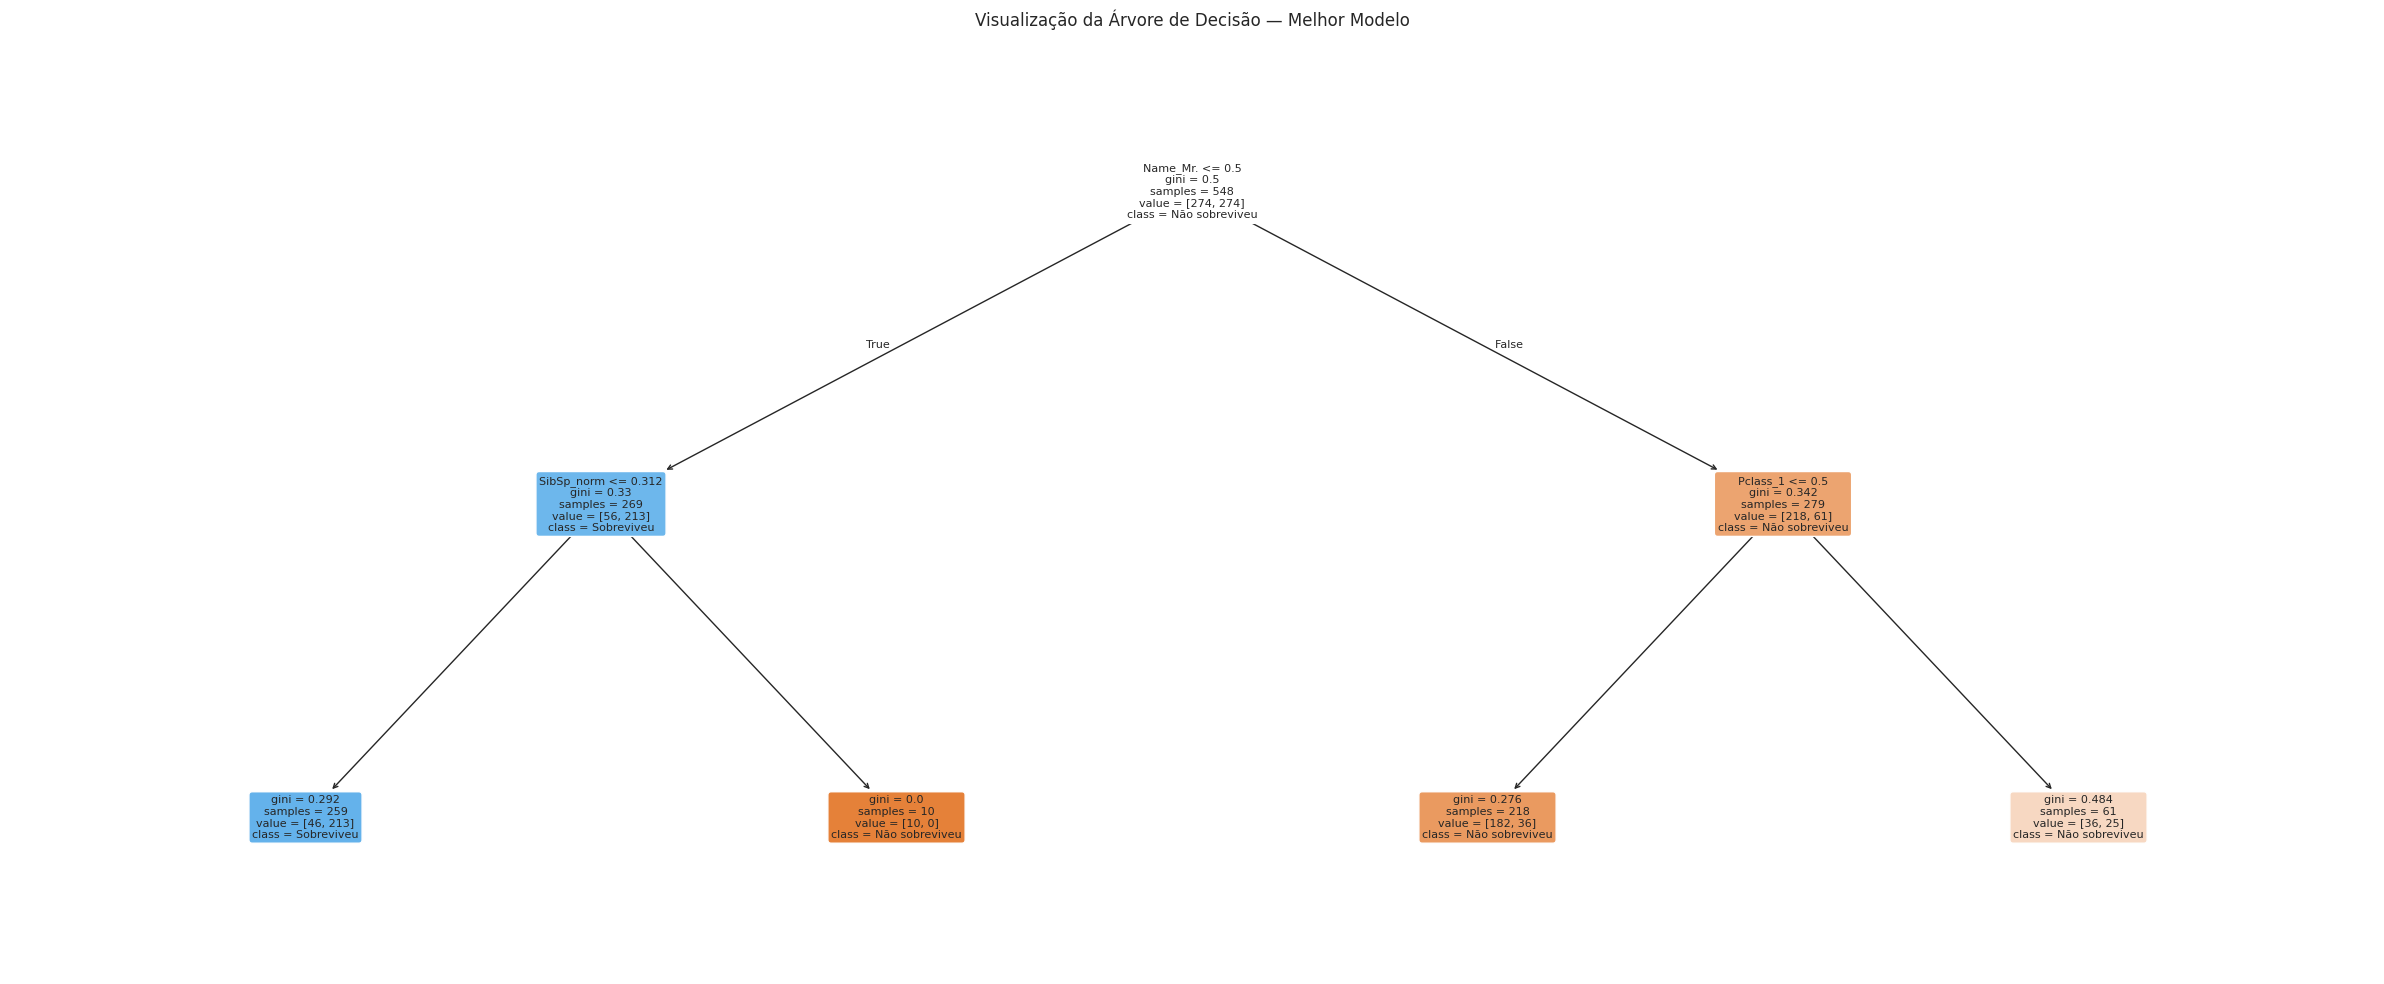

In [ ]:
plt.figure(figsize=(24, 10))
plot_tree(
    melhor_dt,
    feature_names=X_train_bal.columns.tolist(),
    class_names=['Não sobreviveu', 'Sobreviveu'],
    filled=True, rounded=True, fontsize=8
)
plt.title('Visualização da Árvore de Decisão — Melhor Modelo')
plt.tight_layout(); plt.show()

### **Importância das Features**

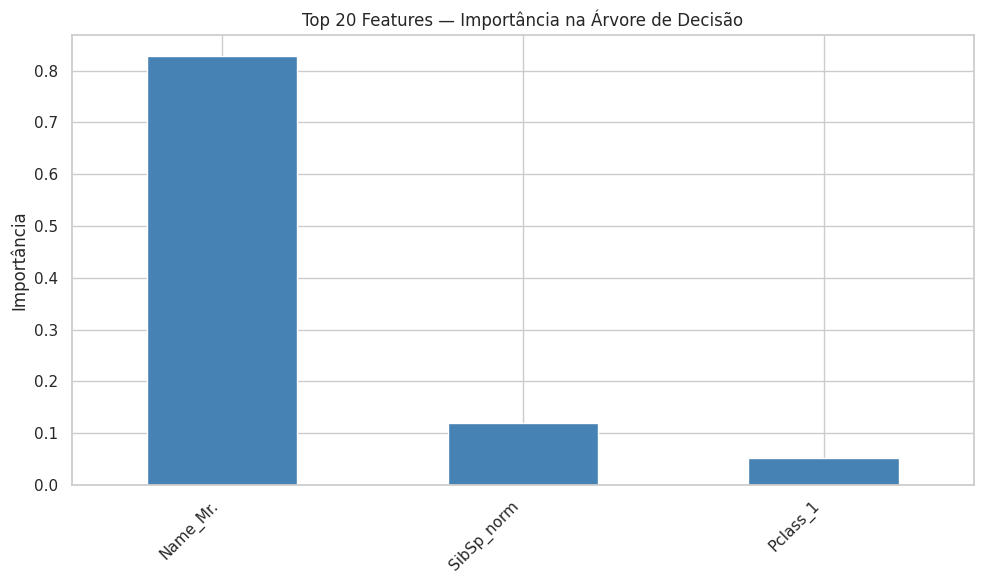

In [ ]:
importancias = pd.Series(
    melhor_dt.feature_importances_, index=X_train_bal.columns
).sort_values(ascending=False)

top_features = importancias[importancias > 0].head(20)
plt.figure(figsize=(10, 6))
top_features.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Top 20 Features — Importância na Árvore de Decisão')
plt.ylabel('Importância'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

### **Avaliação de Desempenho**

In [ ]:
for nome, X, y in [('Validação', X_val, y_val), ('Teste', X_test, y_test)]:
    pred = melhor_dt.predict(X)
    print(f'=== {nome} ===')
    print(f'Acurácia : {accuracy_score(y, pred):.4f}')
    print(f'Precisão : {precision_score(y, pred):.4f}')
    print(f'Recall   : {recall_score(y, pred):.4f}')
    print(f'F1-Score : {f1_score(y, pred):.4f}')
    print()
    print(classification_report(y, pred, target_names=['Não sobreviveu', 'Sobreviveu']))

=== Validação ===
Acurácia : 0.8520
Precisão : 0.8193
Recall   : 0.7907
F1-Score : 0.8047

                precision    recall  f1-score   support

Não sobreviveu       0.87      0.89      0.88       137
    Sobreviveu       0.82      0.79      0.80        86

      accuracy                           0.85       223
     macro avg       0.85      0.84      0.84       223
  weighted avg       0.85      0.85      0.85       223

=== Teste ===
Acurácia : 0.7937
Precisão : 0.7349
Recall   : 0.7176
F1-Score : 0.7262

                precision    recall  f1-score   support

Não sobreviveu       0.83      0.84      0.83       138
    Sobreviveu       0.73      0.72      0.73        85

      accuracy                           0.79       223
     macro avg       0.78      0.78      0.78       223
  weighted avg       0.79      0.79      0.79       223



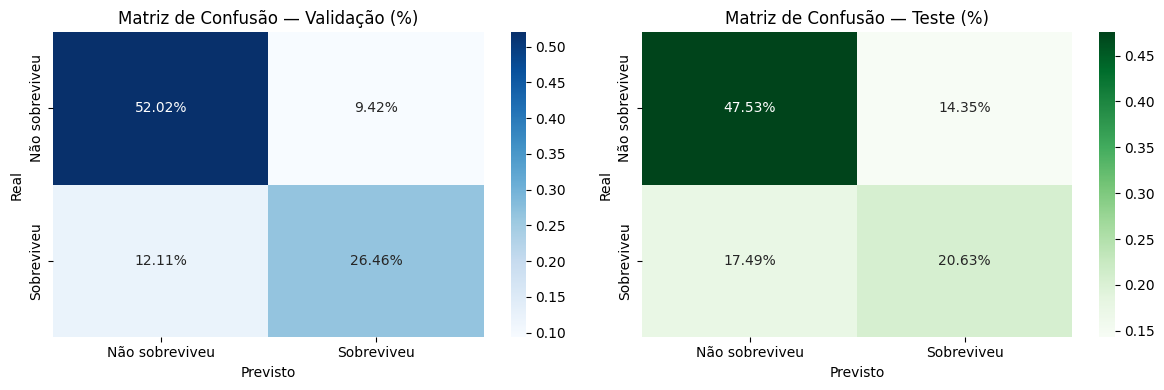

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (nome, X, y), cmap in zip(
    axes,
    [('Validação', X_val, y_val), ('Teste', X_test, y_test)],
    ['Blues', 'Greens']
):
    pred = melhor_dt.predict(X)

    cm = confusion_matrix(y, pred)
    cm_pct = cm / cm.sum()

    sns.heatmap(cm_pct, annot=True, fmt='.2%', cmap=cmap,
                xticklabels=['Não sobreviveu', 'Sobreviveu'],
                yticklabels=['Não sobreviveu', 'Sobreviveu'], ax=ax)

    ax.set_title(f'Matriz de Confusão — {nome} (%)')
    ax.set_ylabel('Real'); ax.set_xlabel('Previsto')

plt.tight_layout(); plt.show()

,Acurácia,Precisão,Recall,F1-Score
Split,,,,
Treino,0.8047,0.8224,0.7774,0.7992
Validação,0.8520,0.8193,0.7907,0.8047
Teste,0.7937,0.7349,0.7176,0.7262


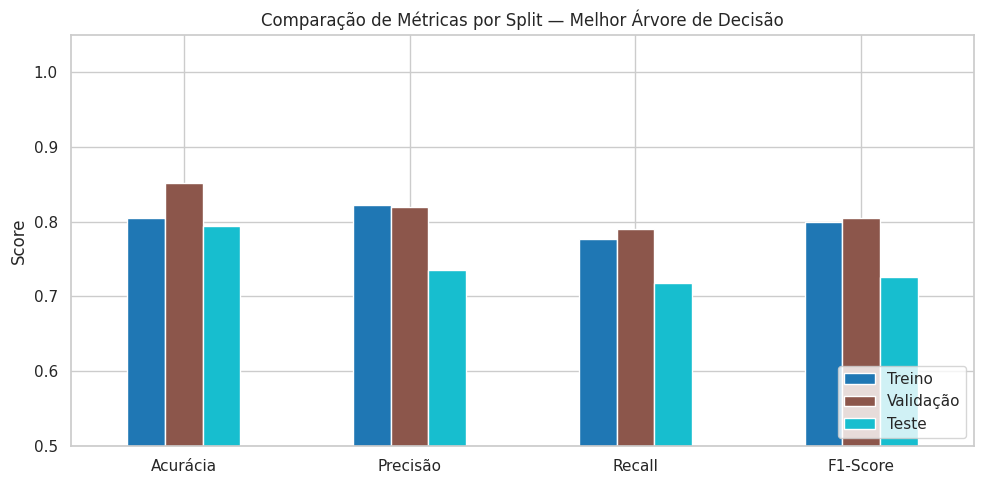

In [ ]:
splits = {
    'Treino'   : (X_train_bal, y_train_bal),
    'Validação': (X_val, y_val),
    'Teste'    : (X_test, y_test),
}
rows = []
for nome, (X, y) in splits.items():
    pred = melhor_dt.predict(X)
    rows.append({'Split': nome,
                 'Acurácia': accuracy_score(y, pred),
                 'Precisão': precision_score(y, pred),
                 'Recall'  : recall_score(y, pred),
                 'F1-Score': f1_score(y, pred)})
df_resultados = pd.DataFrame(rows).set_index('Split')
display(df_resultados.round(4))

df_resultados.T.plot(kind='bar', figsize=(10, 5), colormap='tab10', edgecolor='white')
plt.title('Comparação de Métricas por Split — Melhor Árvore de Decisão')
plt.ylabel('Score'); plt.ylim(0.5, 1.05); plt.xticks(rotation=0)
plt.legend(loc='lower right'); plt.tight_layout(); plt.show()

,Acurácia,Precisão,Recall,F1-Score
Modelo,,,,
Baseline (dados brutos),0.6323,0.5181,0.5059,0.5119
Melhor Modelo (pré-processado),0.7937,0.7349,0.7176,0.7262


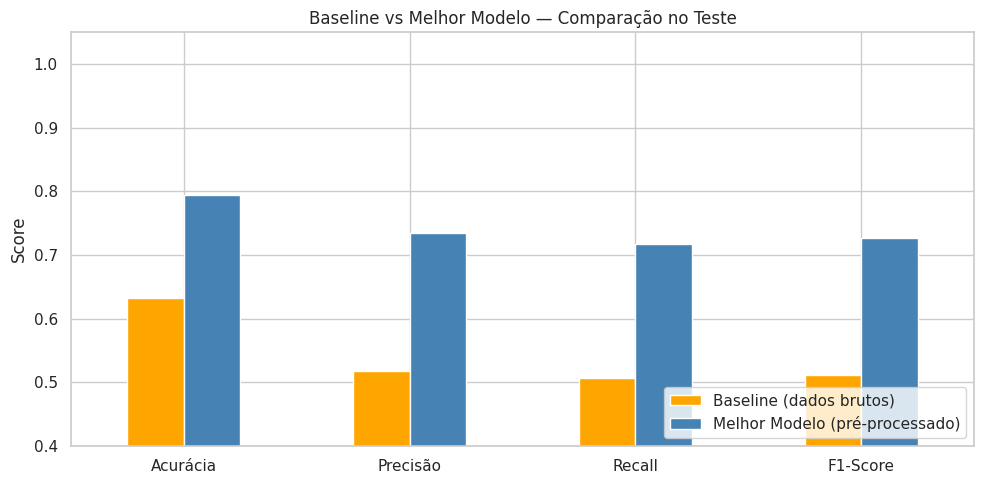

In [ ]:
# Comparação Baseline vs Melhor Modelo
pred_base = dt_baseline.predict(X_base_test)
pred_best = melhor_dt.predict(X_test)

comparativo = pd.DataFrame({
    'Modelo'   : ['Baseline (dados brutos)', 'Melhor Modelo (pré-processado)'],
    'Acurácia' : [accuracy_score(y_base_test, pred_base), accuracy_score(y_test, pred_best)],
    'Precisão' : [precision_score(y_base_test, pred_base), precision_score(y_test, pred_best)],
    'Recall'   : [recall_score(y_base_test, pred_base), recall_score(y_test, pred_best)],
    'F1-Score' : [f1_score(y_base_test, pred_base), f1_score(y_test, pred_best)],
}).set_index('Modelo')

display(comparativo.round(4))
comparativo.T.plot(kind='bar', figsize=(10, 5), color=['orange', 'steelblue'], edgecolor='white')
plt.title('Baseline vs Melhor Modelo — Comparação no Teste')
plt.ylabel('Score'); plt.ylim(0.4, 1.05); plt.xticks(rotation=0)
plt.legend(loc='lower right'); plt.tight_layout(); plt.show()